# Choice Explanation:

- **Dataset Management**: Rather than using `nn.CocoDetection`, which returns a lot of metadata that is unnecessary for our purpose, a `CocoSegmentationDataset` class was developed to create the masks and retain only the image and mask for our segmentation dataset.
- **Optimization**: To speed up training, we use only 10,000 random images from the training dataset. We have configured the neural network and data loaders to use one or more GPUs (options: num_workers, pin_memory, DataParallel, etc.).
- **Training hyperparameters**: We use the BCEWithLogitsLoss loss function, which is often used for binary classification (which is our case, since we are performing foreground/background segmentation), coupled with an Adam optimizer (widely used) configured with a small learning rate of 1e-4 to ensure stable convergence.

# Download data (if needed)

## Download COCO dataset

In [1]:
import kagglehub
dataset_path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

# Import libraries and define constants

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.datasets as dset
import torchvision.transforms as transforms

from PIL import Image
from pycocotools.coco import COCO
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import random_split
import random

In [3]:
PATH_TO_IMAGES_TRAIN = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"
PATH_TO_ANNOTATIONS_TRAIN = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json"

PATH_TO_IMAGES_VAL = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/"
PATH_TO_ANNOTATIONS_VAL = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json"

# Allows to use GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


# Load Dataset

In [4]:
class CocoSegmentationDataset(Dataset):
    def __init__(self, image_dir, annotation_file, image_size=(256, 256)):
        self.coco = COCO(annotation_file)
        self.image_ids = list(self.coco.imgs.keys())
        self.image_dir = image_dir
        self.image_size = image_size

        self.image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor()
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize(
                image_size,
                interpolation=transforms.InterpolationMode.NEAREST
            )
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.coco.loadImgs(image_id)[0]
        image_path = f"{self.image_dir}/{image_info['file_name']}"
        image = Image.open(image_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        anns = self.coco.loadAnns(ann_ids)

        h = image_info["height"]
        w = image_info["width"]

        mask = np.zeros((h, w), dtype=np.uint8)

        for ann in anns:
            ann_mask = self.coco.annToMask(ann)
            mask[ann_mask > 0] = 1

        image = self.image_transform(image)

        mask = Image.fromarray(mask)
        mask = self.mask_transform(mask)
        mask = torch.from_numpy(np.array(mask)).float().unsqueeze(0)

        return image, mask

In [5]:
# Create the datasets with images and masks
train_dataset = CocoSegmentationDataset(
    image_dir=PATH_TO_IMAGES_TRAIN,
    annotation_file=PATH_TO_ANNOTATIONS_TRAIN,
    image_size=(256, 256)
)

val_dataset = CocoSegmentationDataset(
    image_dir=PATH_TO_IMAGES_VAL,
    annotation_file=PATH_TO_ANNOTATIONS_VAL,
    image_size=(256, 256)
)

loading annotations into memory...
Done (t=15.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.71s)
creating index...
index created!


In [6]:
# Pick a subset of the dataset for faster training
subset_indices = torch.randperm(len(train_dataset))[:10000]
train_dataset = torch.utils.data.Subset(train_dataset, subset_indices)

In [7]:
# Create the dataloader for training dataset
train_dataloader = DataLoader(
    train_dataset,
    batch_size=16, # 8 for single GPU
    shuffle=True,
    pin_memory=True,
    num_workers=4 # 2 is classic
)

# Create the dataloader for the validation dataset
val_dataloader = DataLoader(
    val_dataset,
    batch_size=16, # 8 for single GPU
    shuffle=False,
    pin_memory=True,
    num_workers=4 # 2 is classic
)

# U-Net Implementation

In [8]:
class Unet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding="same"),
            nn.ReLU())
        
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 =  nn.Sequential(
            nn.Conv2d(64, 128, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding="same"),
            nn.ReLU())
        
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding="same"),
            nn.ReLU())
        
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding="same"),
            nn.ReLU())

        self.pool4 = nn.MaxPool2d(2)

        self.enc5 = nn.Sequential(
            nn.Conv2d(512, 1024, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(1024, 1024, 3, padding="same"),
            nn.ReLU())


        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        
        self.dec1 = nn.Sequential(
            nn.Conv2d(1024, 512, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding="same"),
            nn.ReLU())

        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)

        self.dec2 = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding="same"),
            nn.ReLU())

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)

        self.dec3 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding="same"),
            nn.ReLU())


        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        
        self.dec4 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding="same"),
            nn.ReLU())

        self.final_conv = nn.Conv2d(64, 1, 1, padding="same")

    def forward(self, x):
        # Encoding
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.enc3(self.pool2(x2))
        x4 = self.enc4(self.pool3(x3))
        x5 = self.enc5(self.pool4(x4))

        # Decoding with skip connections
        d1 = self.up1(x5)
        d1 = torch.cat((d1, x4), dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat((d2, x3), dim=1)
        d2 = self.dec2(d2)
        
        d3 = self.up3(d2)
        d3 = torch.cat((d3, x2), dim=1)
        d3 = self.dec3(d3)
        
        d4 = self.up4(d3)
        d4 = torch.cat((d4, x1), dim=1)
        d4 = self.dec4(d4)
        
        return self.final_conv(d4)
        

# Train the model

In [9]:
# Create the neural network
unet = Unet().to(DEVICE)

# Use multiple GPU if possible
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    unet = nn.DataParallel(unet)

Using 2 GPUs


In [10]:
# Define hyper parameters
epochs = 5
learning_rate = 1e-4
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(unet.parameters(), lr=learning_rate)

In [11]:
# Train the U-Net
for i in range(epochs):
    print(f"Epoch {{{i + 1}/{epochs}}}")
    unet.train()
    # Iterate over each batch
    for batch_idx, (X, y) in enumerate(train_dataloader):
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = unet(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print(f"[{batch_idx}/{len(train_dataloader)}] loss: {loss.item():.4f}")
    # See the performance on the validation dataset
    unet.eval()
    with torch.inference_mode():
        bce_losses = []
        dice_scores = []
        for X, y in val_dataloader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred = unet(X)
            # Compute loss
            score = loss_fn(pred, y).item()
            bce_losses.append(score)
            # Compute DICE
            p = (torch.sigmoid(pred) > 0.5).float()
            intersection = (p * y).sum()
            dice = (2 * intersection) / (p.sum() + y.sum() + 1e-8)
            dice_scores.append(dice.item())
        
        bce_losses = np.array(bce_losses)
        dice_scores = np.array(dice_scores)
        print(f"Mean BCE Loss: {np.mean(bce_losses):.4f}")
        print(f"Mean Dice Score: {np.mean(dice_scores):.4f}")

Epoch {1/5}
[0/625] loss: 0.6543
[100/625] loss: 0.6117
[200/625] loss: 0.4710
[300/625] loss: 0.5420
[400/625] loss: 0.4707
[500/625] loss: 0.4990
[600/625] loss: 0.4851
Mean BCE Loss: 0.5092
Mean Dice Score: 0.3593
Epoch {2/5}
[0/625] loss: 0.5706
[100/625] loss: 0.4967
[200/625] loss: 0.4300
[300/625] loss: 0.4251
[400/625] loss: 0.4755
[500/625] loss: 0.5013
[600/625] loss: 0.3806
Mean BCE Loss: 0.5557
Mean Dice Score: 0.6071
Epoch {3/5}
[0/625] loss: 0.6180
[100/625] loss: 0.4143
[200/625] loss: 0.3785
[300/625] loss: 0.4285
[400/625] loss: 0.5159
[500/625] loss: 0.4322
[600/625] loss: 0.5264
Mean BCE Loss: 0.4728
Mean Dice Score: 0.6142
Epoch {4/5}
[0/625] loss: 0.3245
[100/625] loss: 0.4629
[200/625] loss: 0.4329
[300/625] loss: 0.4179
[400/625] loss: 0.3170
[500/625] loss: 0.4539
[600/625] loss: 0.4063
Mean BCE Loss: 0.4544
Mean Dice Score: 0.5521
Epoch {5/5}
[0/625] loss: 0.3765
[100/625] loss: 0.3435
[200/625] loss: 0.4994
[300/625] loss: 0.4173
[400/625] loss: 0.5196
[500/62

# Visualisation

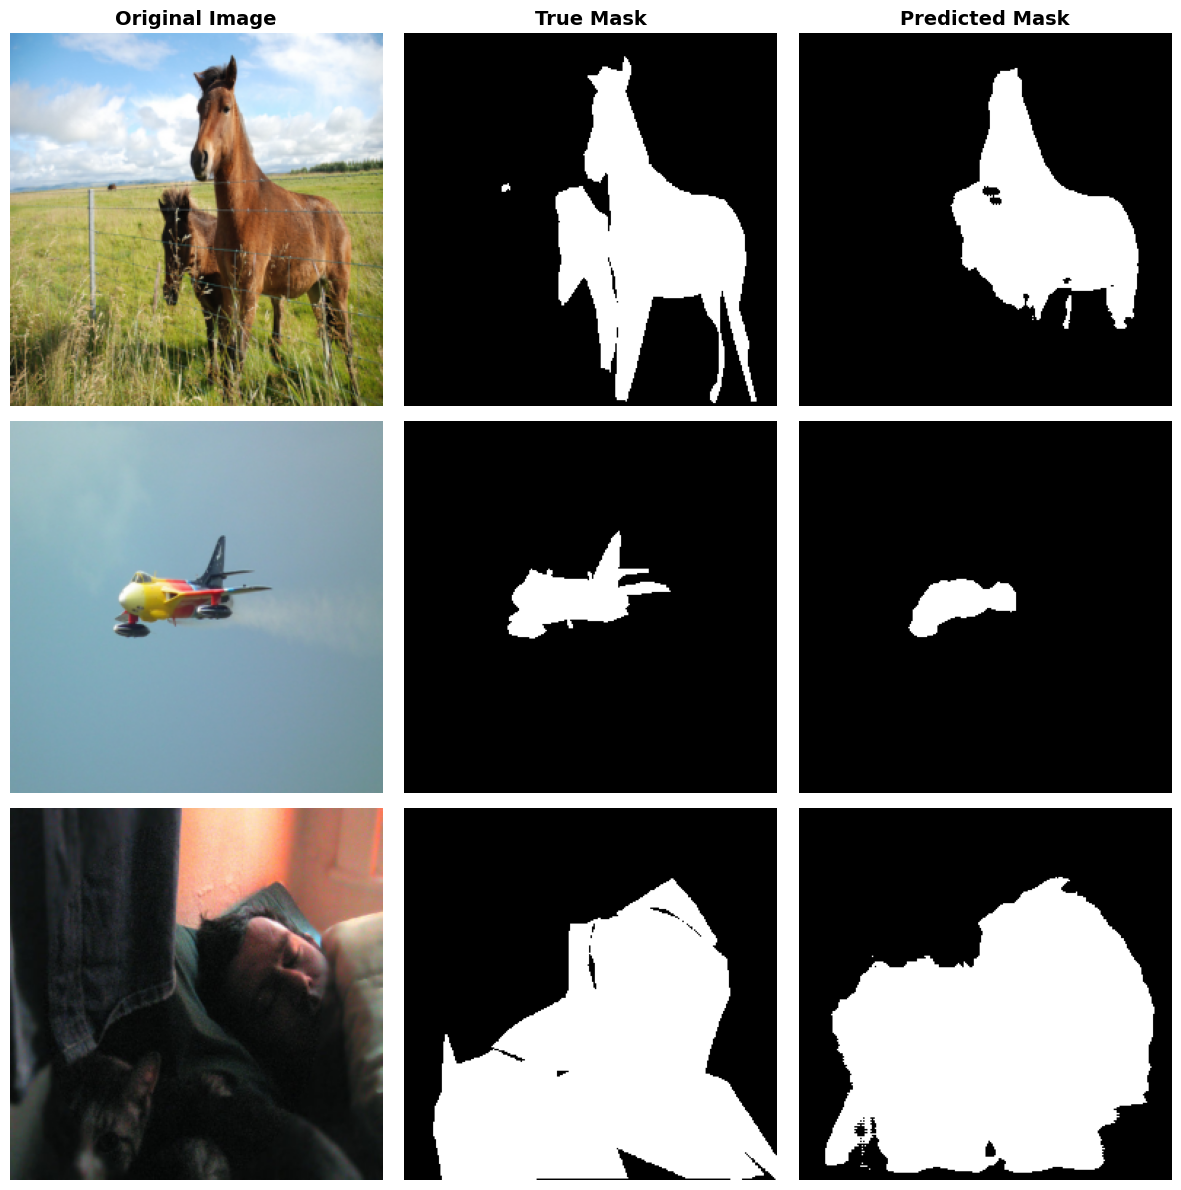

In [26]:
# Define the number of images to test
NUMBER_OF_IMAGES = 3

fig = plt.figure(figsize=(12, 4 * NUMBER_OF_IMAGES))

unet.eval()
with torch.inference_mode():
    for i in range(NUMBER_OF_IMAGES):
        # Choose random image
        random_idx = random.randint(0, len(val_dataset) - 1)
        image, target = val_dataset[random_idx]
        
        # Predict the mask from the image
        input_tensor = image.unsqueeze(0).to(DEVICE) 
        pred = unet(input_tensor)
        pred_to_show = (torch.sigmoid(pred).squeeze() > 0.5).cpu()
        
        # Base line index for plotting
        base_idx = i * 3

        # Show original image
        plt.subplot(NUMBER_OF_IMAGES, 3, base_idx + 1)
        plt.imshow(image.permute(1, 2, 0))  
        plt.axis('off')
        if i == 0: 
            plt.title("Original Image", fontsize=14, fontweight='bold')

        # True mask
        plt.subplot(NUMBER_OF_IMAGES, 3, base_idx + 2)
        plt.imshow(target.squeeze(), cmap="binary_r")  
        plt.axis('off')
        if i == 0: 
            plt.title("True Mask", fontsize=14, fontweight='bold')

        # Predicted mask
        plt.subplot(NUMBER_OF_IMAGES, 3, base_idx + 3)
        plt.imshow(pred_to_show, cmap="binary_r")  
        plt.axis('off')
        if i == 0: 
            plt.title("Predicted Mask", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Result explanation

As we can see, the results aren’t perfect. First of all, we coded a “basic” U-Net from scratch, which could be improved, for example by including batch normalization layers. Also, ideally, we would benchmark the hyperparameters (learning rate, number of epochs, loss function, etc.) to optimize them. However, training the model takes a long time, even with Kaggle’s GPUs, and conducting these tests would be extremely time-consuming. Furthermore, we only ran 5 epochs and trained the model on just 10,000 images, whereas the full training dataset contains over 118,000. The COCO dataset is complex because it contains a vast number of very different objects, and training on the entire dataset would yield better results.